# rishi_rmsnorm Benchmark — RTX 5080, sm_120

Comparing rishi's kernel against the V1–V5 CUDA kernels and Python baselines.

| Kernel | Strategy | HBM passes |
|--------|----------|------------|
| V1 | One thread per row — serial, non-coalesced | 2R + 1W |
| V2 | One block/row — 256 threads, warp+block reduction | 2R + 1W |
| V3 | One block/row — 128 threads, warp+block reduction | 2R + 1W |
| V4 | float4 vectorized loads, 128 threads | 2R + 1W |
| V5 | xor butterfly, no smem broadcast, 128 threads | 2R + 1W |
| **rishi** | **vec4 + register cache + xor butterfly, 128 threads** | **1R + 1W** |

**Data collection:**
```bash
# 1. Python baselines — outputs CSV: size,pytorch_us,compiled_us,triton_us
python benchmark/sweep_rmsnorm.py

# 2. CUDA timings — read 'Median Time (ms)' × 1000 → µs
./build/bin/RMSNorm_sm120  512 1024
./build/bin/RMSNorm_sm120 1024 1024
./build/bin/RMSNorm_sm120 2048 1024
./build/bin/RMSNorm_sm120 4096 1024
./build/bin/RMSNorm_sm120 8192 1024
./build/bin/RMSNorm_sm120 8192 2048
./build/bin/RMSNorm_sm120 8192 4096

# 3. rishi kernel
./build/bin/rishi_rmsnorm  512 1024
./build/bin/rishi_rmsnorm 1024 1024
./build/bin/rishi_rmsnorm 2048 1024
./build/bin/rishi_rmsnorm 4096 1024
./build/bin/rishi_rmsnorm 8192 1024
./build/bin/rishi_rmsnorm 8192 2048
./build/bin/rishi_rmsnorm 8192 4096
```

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ── Data (µs) ─────────────────────────────────────────────────────────────────
# CUDA timings: Median Time (ms) × 1000  from ./build/bin/RMSNorm_sm120 N C
# Python baselines: from  python benchmark/sweep_rmsnorm.py
# rishi timings:  from ./build/bin/rishi_rmsnorm N C

sizes = [
    '512×1024', '1024×1024', '2048×1024', '4096×1024',
    '8192×1024', '8192×2048', '8192×4096'
]

v1       = [ 329.7, 327.7, 325.3, 329.4, 368.6,  626.7, 1261.6]
v2       = [  12.3,  14.3,  22.5,  45.1,  85.7,  170.0,  335.9]
v3       = [  10.2,  18.4,  24.6,  38.9,  79.9,  170.0,  380.9]
rishi    = [   6.1,  10.2,  20.2,  36.9,  75.8,  161.8,  329.7]
pytorch  = [   7.9,  12.3,  24.3,  45.1,  87.6,  167.9,  358.1]
compiled = [   6.1,   9.9,  20.2,  43.0,  84.0,  165.9,  327.7]
triton   = [   7.8,  11.9,  22.2,  42.7,  84.0,  165.5,  327.3]

# ── Dark theme ────────────────────────────────────────────────────────────────
BG     = '#0d1117'
PANEL  = '#161b22'
GRID_C = '#ffffff'
TEXT   = '#e6edf3'
BLUE   = '#58a6ff'
ORANGE = '#f78166'
GREEN  = '#3fb950'
PURPLE = '#bc8cff'
YELLOW = '#e3b341'
PINK   = '#ff7b72'
TEAL   = '#39d353'
CYAN   = '#79c0ff'

plt.rcParams.update({
    'font.family':        'monospace',
    'text.color':         TEXT,
    'axes.labelcolor':    TEXT,
    'xtick.color':        TEXT,
    'ytick.color':        TEXT,
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.spines.left':   True,
    'axes.spines.bottom': True,
    'axes.edgecolor':     '#30363d',
    'axes.grid':          True,
    'grid.color':         GRID_C,
    'grid.alpha':         0.06,
    'grid.linestyle':     '-',
    'grid.linewidth':     0.5,
    'figure.facecolor':   BG,
    'axes.facecolor':     PANEL,
})

x = np.arange(len(sizes))
print('Data loaded.')

Data loaded.


## 1 — All kernels: latency across sizes

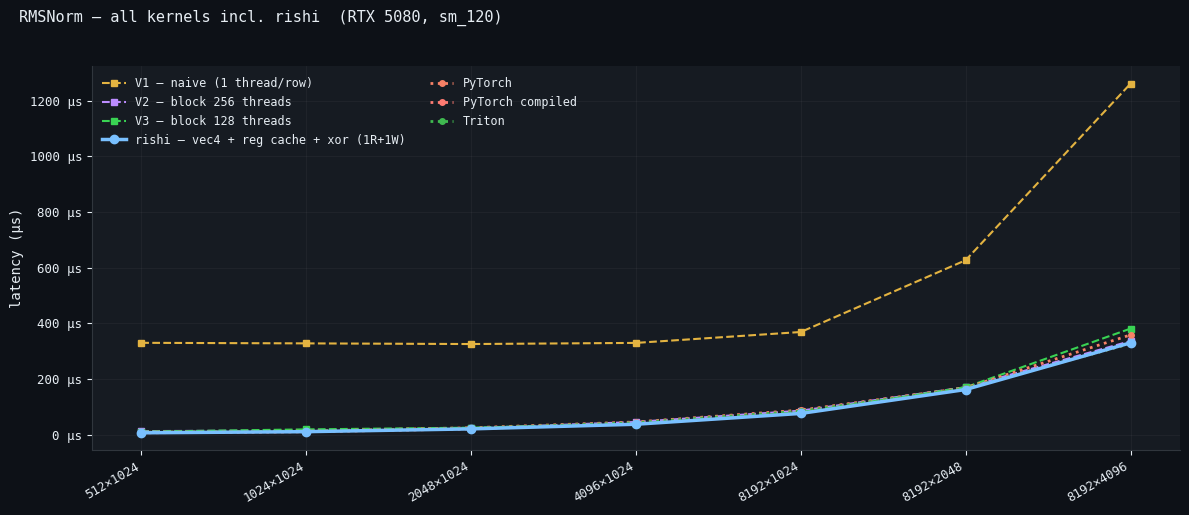

In [14]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(x, v1,       color=YELLOW,  linewidth=1.5, marker='s', markersize=4,
        linestyle='--', label='V1 — naive (1 thread/row)', zorder=2)
ax.plot(x, v2,       color=PURPLE,  linewidth=1.5, marker='s', markersize=4,
        linestyle='--', label='V2 — block 256 threads', zorder=2)
ax.plot(x, v3,       color=TEAL,    linewidth=1.5, marker='s', markersize=4,
        linestyle='--', label='V3 — block 128 threads', zorder=2)
ax.plot(x, rishi,    color=CYAN,    linewidth=2.5, marker='o', markersize=6,
        label='rishi — vec4 + reg cache + xor (1R+1W)', zorder=5)
ax.plot(x, pytorch,  color=ORANGE,  linewidth=2,   marker='o', markersize=4,
        linestyle=':', label='PyTorch', zorder=3)
ax.plot(x, compiled, color=PINK,    linewidth=2,   marker='o', markersize=4,
        linestyle=':', label='PyTorch compiled', zorder=3)
ax.plot(x, triton,   color=GREEN,   linewidth=2,   marker='o', markersize=4,
        linestyle=':', label='Triton', zorder=3)

ax.set_xticks(x)
ax.set_xticklabels(sizes, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('latency (µs)', fontsize=10)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f'{int(v)} µs'))
ax.legend(fontsize=8.5, framealpha=0, loc='upper left', labelcolor=TEXT, ncol=2)
ax.tick_params(labelsize=9)

fig.suptitle('RMSNorm — all kernels incl. rishi  (RTX 5080, sm_120)',
             fontsize=11, fontweight='normal', y=1.02, x=0.02, ha='left', color=TEXT)
plt.tight_layout()
plt.savefig('rishi_rmsnorm_all.png', dpi=180, bbox_inches='tight', facecolor=BG)
plt.show()

## 2 — rishi vs best CUDA (V3) vs baselines

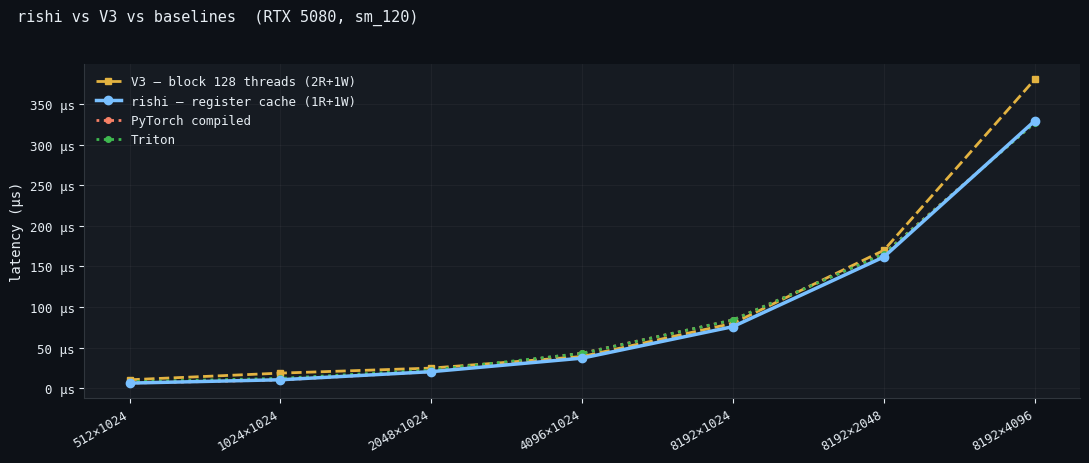

In [15]:
fig, ax = plt.subplots(figsize=(11, 4.5))

ax.plot(x, v3,       color=YELLOW, linewidth=2,   marker='s', markersize=5,
        linestyle='--', label='V3 — block 128 threads (2R+1W)', zorder=3)
ax.plot(x, rishi,    color=CYAN,   linewidth=2.5, marker='o', markersize=6,
        label='rishi — register cache (1R+1W)', zorder=5)
ax.plot(x, compiled, color=ORANGE, linewidth=2,   marker='o', markersize=4,
        linestyle=':', label='PyTorch compiled', zorder=3)
ax.plot(x, triton,   color=GREEN,  linewidth=2,   marker='o', markersize=4,
        linestyle=':', label='Triton', zorder=3)

ax.set_xticks(x)
ax.set_xticklabels(sizes, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('latency (µs)', fontsize=10)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f'{int(v)} µs'))
ax.legend(fontsize=9, framealpha=0, loc='upper left', labelcolor=TEXT)
ax.tick_params(labelsize=9)

fig.suptitle('rishi vs V3 vs baselines  (RTX 5080, sm_120)',
             fontsize=11, fontweight='normal', y=1.02, x=0.02, ha='left', color=TEXT)
plt.tight_layout()
plt.savefig('rishi_rmsnorm_vs_baselines.png', dpi=180, bbox_inches='tight', facecolor=BG)
plt.show()

## 3 — Sizes where rishi beats both PyTorch compiled and Triton

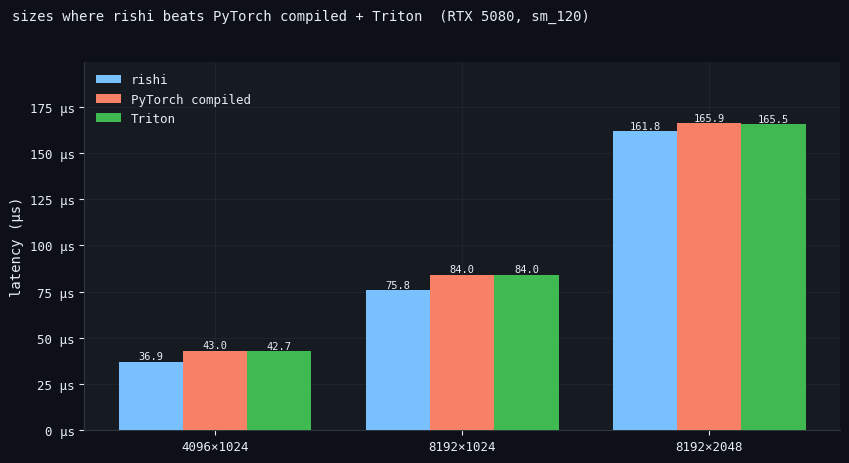

rishi wins at 3/7 sizes tested.


In [16]:
win_idx   = [i for i in range(len(sizes)) if rishi[i] > 0 and rishi[i] < compiled[i] and rishi[i] < triton[i]]
win_sizes = [sizes[i]    for i in win_idx]
r_vals    = [rishi[i]    for i in win_idx]
cmp_vals  = [compiled[i] for i in win_idx]
tri_vals  = [triton[i]   for i in win_idx]

n     = len(win_sizes)
xw    = np.arange(n) if n > 0 else np.arange(1)
width = 0.26

fig, ax = plt.subplots(figsize=(max(6, n * 2.2 + 2), 4.5))

if n > 0:
    b1 = ax.bar(xw - width, r_vals,   width, label='rishi',              color=CYAN,   zorder=3)
    b2 = ax.bar(xw,         cmp_vals, width, label='PyTorch compiled',   color=ORANGE, zorder=3)
    b3 = ax.bar(xw + width, tri_vals, width, label='Triton',             color=GREEN,  zorder=3)

    for bars in (b1, b2, b3):
        for bar in bars:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.3,
                f'{bar.get_height():.1f}',
                ha='center', va='bottom', fontsize=7.5, color=TEXT
            )

    ax.set_xticks(xw)
    ax.set_xticklabels(win_sizes, fontsize=9)
    if r_vals:
        ax.set_ylim(0, max(cmp_vals + tri_vals) * 1.2)
else:
    ax.text(0.5, 0.5, 'no wins yet — fill in data first',
            ha='center', va='center', color=TEXT, fontsize=11, transform=ax.transAxes)

ax.set_ylabel('latency (µs)', fontsize=10)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f'{int(v)} µs'))
ax.legend(fontsize=9, framealpha=0, labelcolor=TEXT)
ax.tick_params(labelsize=9)

fig.suptitle('sizes where rishi beats PyTorch compiled + Triton  (RTX 5080, sm_120)',
             fontsize=10, fontweight='normal', y=1.02, x=0.02, ha='left', color=TEXT)
plt.tight_layout()
plt.savefig('rishi_rmsnorm_wins.png', dpi=180, bbox_inches='tight', facecolor=BG)
plt.show()

print(f'rishi wins at {n}/{len(sizes)} sizes tested.')

## 4 — Kernel progression at 8192×1024

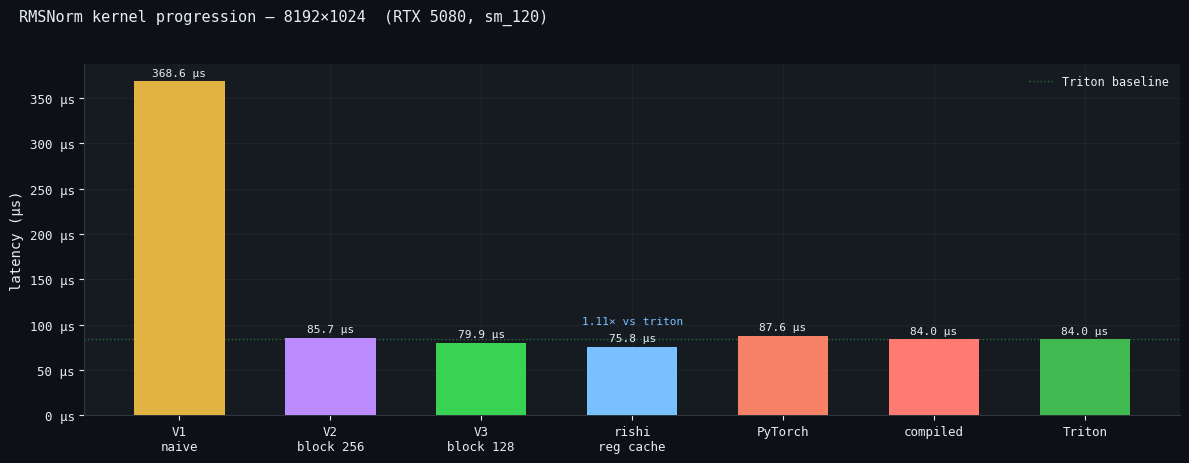

In [17]:
IDX = 4  # 8192×1024

kern_names  = ['V1\nnaive', 'V2\nblock 256', 'V3\nblock 128',
               'rishi\nreg cache', 'PyTorch', 'compiled', 'Triton']
kern_vals   = [v1[IDX], v2[IDX], v3[IDX], rishi[IDX],
               pytorch[IDX], compiled[IDX], triton[IDX]]
kern_colors = [YELLOW, PURPLE, TEAL, CYAN, ORANGE, PINK, GREEN]

fig, ax = plt.subplots(figsize=(12, 4.5))
bars = ax.bar(range(len(kern_names)), kern_vals, color=kern_colors, zorder=3, width=0.6)

max_val = max(kern_vals) if max(kern_vals) > 0 else 1
for bar, val in zip(bars, kern_vals):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max_val * 0.01,
        f'{val:.1f} µs',
        ha='center', va='bottom', fontsize=8, color=TEXT
    )

ax.axhline(triton[IDX], color=GREEN, linewidth=1, linestyle=':', alpha=0.5, label='Triton baseline')

ax.set_xticks(range(len(kern_names)))
ax.set_xticklabels(kern_names, fontsize=9)
ax.set_ylabel('latency (µs)', fontsize=10)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f'{int(v)} µs'))
ax.legend(fontsize=8.5, framealpha=0, labelcolor=TEXT)
ax.tick_params(labelsize=9)

if triton[IDX] > 0 and rishi[IDX] > 0:
    speedup = triton[IDX] / rishi[IDX]
    ax.annotate(
        f'{speedup:.2f}× vs triton',
        xy=(3, rishi[IDX]), xytext=(3, rishi[IDX] + triton[IDX] * 0.3),
        fontsize=8, color=CYAN, ha='center'
    )

fig.suptitle(f'RMSNorm kernel progression — {sizes[IDX]}  (RTX 5080, sm_120)',
             fontsize=11, fontweight='normal', y=1.02, x=0.02, ha='left', color=TEXT)
plt.tight_layout()
plt.savefig('rishi_rmsnorm_progression.png', dpi=180, bbox_inches='tight', facecolor=BG)
plt.show()

## 5 — Speedup of rishi over PyTorch compiled, Triton, and V3 across sizes

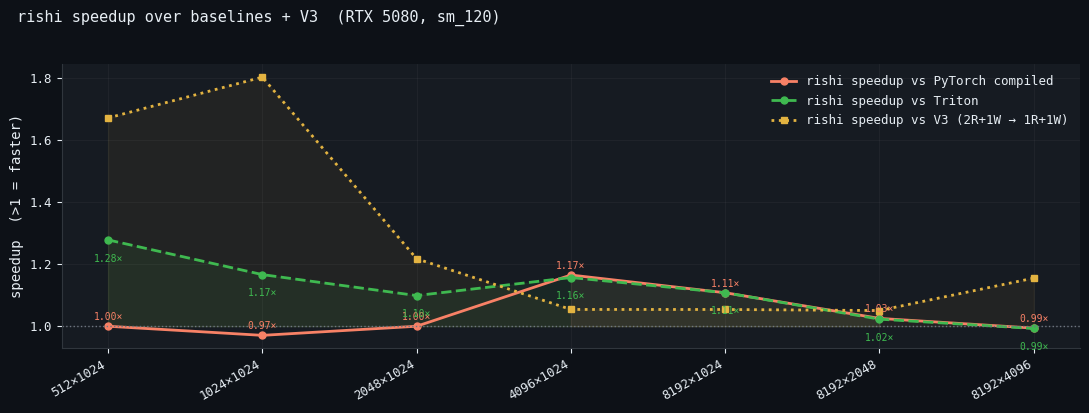

In [18]:
eps = 1e-9
speedups_compiled = [c / (r + eps) for c, r in zip(compiled, rishi)]
speedups_triton   = [t / (r + eps) for t, r in zip(triton,   rishi)]
speedups_v3       = [v / (r + eps) for v, r in zip(v3,       rishi)]

fig, ax = plt.subplots(figsize=(11, 4))

ax.plot(x, speedups_compiled, color=ORANGE, linewidth=2, marker='o', markersize=5,
        label='rishi speedup vs PyTorch compiled')
ax.plot(x, speedups_triton,   color=GREEN,  linewidth=2, marker='o', markersize=5,
        linestyle='--', label='rishi speedup vs Triton')
ax.plot(x, speedups_v3,       color=YELLOW, linewidth=2, marker='s', markersize=5,
        linestyle=':', label='rishi speedup vs V3 (2R+1W → 1R+1W)')

ax.axhline(1.0, color='#6e7681', linewidth=1, linestyle=':')
ax.fill_between(x, 1.0, speedups_compiled,
                where=[s > 1 for s in speedups_compiled],
                color=ORANGE, alpha=0.08)
ax.fill_between(x, 1.0, speedups_triton,
                where=[s > 1 for s in speedups_triton],
                color=GREEN, alpha=0.08)
ax.fill_between(x, 1.0, speedups_v3,
                where=[s > 1 for s in speedups_v3],
                color=YELLOW, alpha=0.06)

for i, (sc, st, sv) in enumerate(zip(speedups_compiled, speedups_triton, speedups_v3)):
    ax.text(i, sc + 0.02, f'{sc:.2f}×', ha='center', fontsize=7, color=ORANGE)
    ax.text(i, st - 0.07, f'{st:.2f}×', ha='center', fontsize=7, color=GREEN)

ax.set_xticks(x)
ax.set_xticklabels(sizes, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('speedup  (>1 = faster)', fontsize=10)
ax.legend(fontsize=9, framealpha=0, labelcolor=TEXT)
ax.tick_params(labelsize=9)

fig.suptitle('rishi speedup over baselines + V3  (RTX 5080, sm_120)',
             fontsize=11, fontweight='normal', y=1.02, x=0.02, ha='left', color=TEXT)
plt.tight_layout()
plt.savefig('rishi_rmsnorm_speedup.png', dpi=180, bbox_inches='tight', facecolor=BG)
plt.show()

## 6 — HBM bandwidth utilisation: rishi vs V3 at 8192×1024

rishi reads input **once** into registers before the second pass — theoretical bandwidth is `2×NBytes` vs `3×NBytes` for V3.

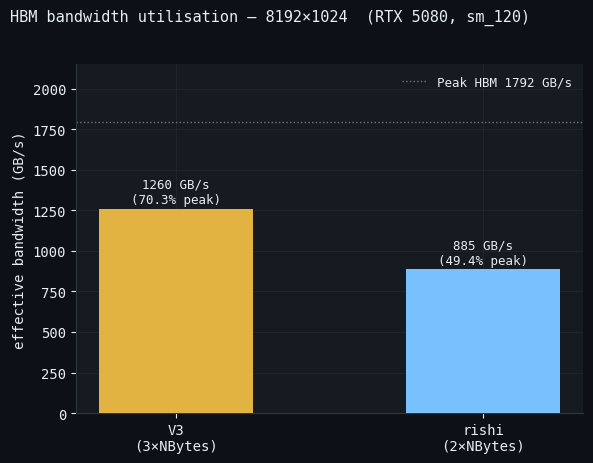

V3    effective BW: 1259.9 GB/s  (70.3% of peak)
rishi effective BW: 885.3 GB/s  (49.4% of peak)


In [19]:
IDX   = 4   # 8192×1024
N, C  = 8192, 1024
PEAK_BW = 1792.0  # GB/s  (RTX 5080 theoretical)

NBytes = N * C * 4  # bytes (float32)

# Effective bandwidth: bytes / time
bw_v3    = (3 * NBytes / 1e9) / (v3[IDX]    * 1e-6) if v3[IDX]    > 0 else 0
bw_rishi = (2 * NBytes / 1e9) / (rishi[IDX] * 1e-6) if rishi[IDX] > 0 else 0

labels = ['V3\n(3×NBytes)', 'rishi\n(2×NBytes)']
vals   = [bw_v3, bw_rishi]
colors = [YELLOW, CYAN]

fig, ax = plt.subplots(figsize=(6, 4.5))
bars = ax.bar(labels, vals, color=colors, zorder=3, width=0.5)

ax.axhline(PEAK_BW, color='#6e7681', linewidth=1, linestyle=':', label=f'Peak HBM {PEAK_BW:.0f} GB/s')

for bar, val in zip(bars, vals):
    pct = val / PEAK_BW * 100
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + PEAK_BW * 0.01,
        f'{val:.0f} GB/s\n({pct:.1f}% peak)',
        ha='center', va='bottom', fontsize=9, color=TEXT
    )

ax.set_ylim(0, PEAK_BW * 1.2)
ax.set_ylabel('effective bandwidth (GB/s)', fontsize=10)
ax.legend(fontsize=9, framealpha=0, labelcolor=TEXT)
ax.tick_params(labelsize=10)

fig.suptitle(f'HBM bandwidth utilisation — {sizes[IDX]}  (RTX 5080, sm_120)',
             fontsize=11, fontweight='normal', y=1.02, x=0.02, ha='left', color=TEXT)
plt.tight_layout()
plt.savefig('rishi_rmsnorm_bandwidth.png', dpi=180, bbox_inches='tight', facecolor=BG)
plt.show()

print(f'V3    effective BW: {bw_v3:.1f} GB/s  ({bw_v3/PEAK_BW*100:.1f}% of peak)')
print(f'rishi effective BW: {bw_rishi:.1f} GB/s  ({bw_rishi/PEAK_BW*100:.1f}% of peak)')